In [1]:
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
import os
import liana as li
from liana.method import cellphonedb, cellchat
from tqdm import tqdm
#liana dotplot returns a ggsave object...
from plotnine import ggsave, ggplot
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
H = ["IndividualMiceData/GF_HF_6B_CellPhoneDB.h5ad","IndividualMiceData/GF_HF_13L_CellPhoneDB.h5ad"]
D = ["IndividualMiceData/GF_HFVHC_5A_CellPhoneDB.h5ad","IndividualMiceData/GF_HFVHC_16L_CellPhoneDB.h5ad"]
data = {}
data["H1"] = sc.read_h5ad(H[0])
data["H2"] = sc.read_h5ad(H[1])
# data["H3"] = sc.read_h5ad(H[2])
data["D1"] = sc.read_h5ad(D[0])
data["D2"] = sc.read_h5ad(D[1])
# data["D3"] = sc.read_h5ad(D[2])

In [3]:
score = {}
for t in ["H","D"]:
    # for i in [1,2,3]:
    for i in [1,2]:
        data_key = t+str(i)
        data_curr = data[data_key]
        for s in ['cDC1s','cDC2s','Mig. cDCs','pDCs']:
            for l in ['H2-Aa','H2-Ab1']:
                for r in ['Cd4', 'Lag3']:
                    x = data_curr.uns["cpdb_res"][data_curr.uns["cpdb_res"].ligand == l]\
                    [data_curr.uns["cpdb_res"].receptor == r]\
                    [data_curr.uns["cpdb_res"].target == 'T cells']\
                    [data_curr.uns["cpdb_res"].source == s]
                    if x.empty:
                        score[(data_key, s, l, r)] = 0
                    else:
                        score[(data_key, s, l, r)] = x.lr_means.iloc[0]

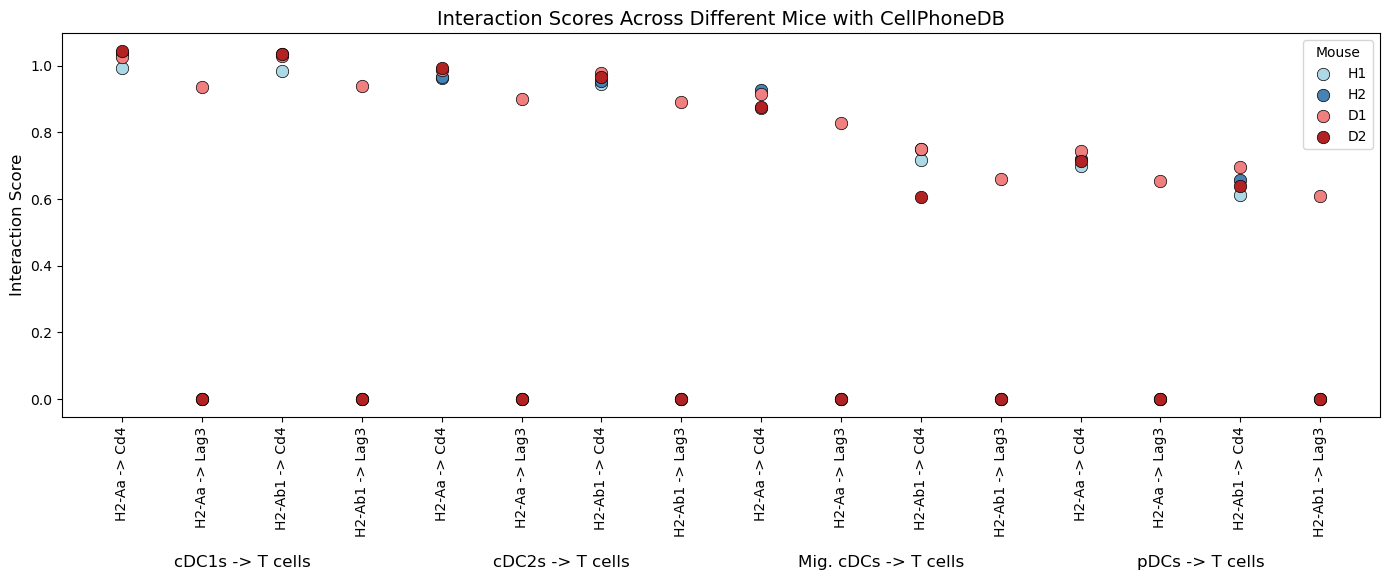

In [5]:
# Convert the dictionary to a DataFrame
df = pd.DataFrame(list(score.items()), columns=['interactions', 'cc_score'])

# Split the 'interactions' tuple into separate columns
df[['Mouse', 'Source', 'Ligand', 'Receptor']] = pd.DataFrame(df['interactions'].tolist(), index=df.index)

# Create the Source -> Target column
df['Source -> Target'] = df['Source'] + ' -> T cells'

# Create the Ligand -> Receptor column
df['Ligand -> Receptor'] = df['Ligand'] + ' -> ' + df['Receptor']

# Define the order of the outer x-axis categories
outer_order = ['cDC1s -> T cells', 'cDC2s -> T cells', 'Mig. cDCs -> T cells', 'pDCs -> T cells']

# Define the order of the inner x-axis categories
inner_order = ['H2-Aa -> Cd4', 'H2-Aa -> Lag3', 'H2-Ab1 -> Cd4', 'H2-Ab1 -> Lag3']

# Create the nested x-axis category for plotting
df['Nested_X'] = df['Source -> Target'] + '\n' + df['Ligand -> Receptor']

# Create the figure and subplots
fig, axes = plt.subplots(figsize=(14, 6))

# Define a color palette with outlines
palette = {'H1': 'lightblue', 'H2': 'steelblue', 'D1': 'lightcoral', 'D2': 'firebrick'}

# Use seaborn to create a scatter plot with nested x-axis and outlines
for mouse in df['Mouse'].unique():
    subset = df[df['Mouse'] == mouse]
    axes.scatter(
        x=subset['Nested_X'],
        y=subset['cc_score'],
        s=80,
        color=palette[mouse],
        edgecolor='black',
        linewidth=0.5,
        label=mouse
    )

# Customize the plot
axes.set_ylabel('Interaction Score', fontsize=12)
axes.set_title('Interaction Scores Across Different Mice with CellPhoneDB', fontsize=14)
axes.tick_params(axis='x', rotation=90)
axes.legend(title='Mouse')

# Set the x-axis tick labels to be the 'Ligand -> Receptor'
axes.set_xticklabels(df['Ligand -> Receptor'].tolist())

# Create custom x-axis labels for 'Source -> Target'
unique_sources = df['Source -> Target'].unique()
num_inner = len(inner_order)
source_positions = np.arange(0, len(df), num_inner) + (num_inner - 1) / 2

for i, source in enumerate(unique_sources):
    axes.text(source_positions[i], -0.4, source, ha='center', va='bottom',
              transform=axes.get_xaxis_transform(), fontsize=12)

# Adjust bottom margin to make space for the source labels
plt.subplots_adjust(bottom=0.2)
plt.tight_layout()
plt.savefig('figures/GF_CellPhoneDB_Represent_colored.png')
# plt.show()